In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import urllib3
import ssl
import requests
import io

urllib3.disable_warnings()

### To Print all the color maps

In [23]:
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

### Import the data from Google Sheets

In [2]:
spreadsheet_id = "1myYlsoOTpXPPN9mKfZkEDrX_H5mlAiIPbM0HxA6L0OY"
ssl._create_default_https_context = ssl._create_unverified_context
url = f"https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv"

response = requests.get(url, verify=False)
df = pd.read_csv(io.StringIO(response.text))
pd.set_option('display.max_columns', None)

#df = pd.read_csv('/kaggle/input/datasets/bishop36/aqui-air-index/AQUI Index - aqui.csv')

df.head(10)

,status,station,city,state,country,location,timezone,latitude,longitude,uid,city_lat,city_lon,state_lat,state_lon,updated_at,isOnline,AQI_IN,aqi,co,no2,o3,pm10,pm25,so2,t,clouds,condition,feels_like_c,feels_like_f,gust_kph,gust_mph,humidity,precip_in,precip_mm,pressure_in,pressure_mb,temp_c,temp_f,uv,vis_km,vis_miles,wind_degree,wind_dir,wind_kph,wind_mph,uv_condition,Date
0,success,"Soni Ni Chali, Ahmedabad, Gujarat, India",Ahmedabad,Gujarat,India,Ahmedabad,Asia/Kolkata,23.0225,72.5714,VIR215,23.0225,72.5714,22.3850,71.7453,2026-02-01T11:51:01.000Z,True,311,209,288.0,46.0,22.0,169,141,17.0,NaN,0,Mist,24.4,75.9,5.8,3.6,61,0.00,0.00,30.06,1018,24.1,75.4,5.0,1.2,0,51,NE,5.0,3.1,Moderate,2/1/2026
1,success,"ISRO Colony, Bangalore, Karnataka, India",Bangalore,Karnataka,India,Bangalore,Asia/Kolkata,12.9789,77.5917,PLLODA000328,12.9789,77.5917,14.5204,75.7224,2026-02-01T11:51:01.000Z,True,87,135,271.0,17.0,29.0,68,52,2.0,NaN,25,Mist,24.7,76.5,20.3,12.6,47,0.00,0.00,30.18,1022,24.3,75.7,10.5,5.0,3,100,E,17.6,11.0,Extreme,2/1/2026
2,success,"Kazhikundram, Chennai, Tamil Nadu, India",Chennai,Tamil Nadu,India,Chennai,Asia/Kolkata,13.0825,80.2750,11279,13.0825,80.2750,10.9094,78.3665,2026-02-01T11:41:01.000Z,True,87,141,366.0,4.0,11.0,66,52,2.0,NaN,50,Partly cloudy,31.2,88.1,24.8,15.4,70,0.00,0.01,30.03,1017,29.0,84.2,8.8,6.0,3,51,NE,21.6,13.4,Very High,2/1/2026
3,success,"Kompally, Hyderabad, Telangana, India",Hyderabad,Telangana,India,Hyderabad,Asia/Kolkata,17.4399,78.4983,14149,17.4399,78.4983,17.8496,79.1152,2026-02-01T11:41:01.000Z,True,239,181,262.0,7.0,17.0,127,102,3.0,NaN,25,Mist,25.0,77.0,16.2,10.0,57,0.00,0.00,30.18,1022,24.0,75.2,7.6,4.0,2,121,ESE,14.0,8.7,Very High,2/1/2026
4,success,"Kamardanga, Kolkata, West Bengal, India",Kolkata,West Bengal,India,Kolkata,Asia/Kolkata,22.6200,88.4200,VIR5520,22.6200,88.4200,22.9965,87.6856,2026-02-01T11:41:01.000Z,True,232,179,356.0,22.0,12.0,122,100,2.0,NaN,50,Mist,22.6,72.7,15.3,9.5,50,0.00,0.00,30.09,1019,23.0,73.4,6.3,2.8,1,348,NNW,13.3,8.3,High,2/1/2026
5,success,"Mahim, Mumbai, Maharashtra, India",Mumbai,Maharashtra,India,Mumbai,Asia/Kolkata,19.0761,72.8775,13715,19.0761,72.8775,18.9068,75.6742,2026-02-01T11:41:01.000Z,True,291,202,252.0,30.0,17.0,152,127,4.0,NaN,0,Mist,32.7,90.9,8.9,5.5,55,0.00,0.00,30.03,1017,29.3,84.7,5.8,1.6,0,354,N,6.1,3.8,High,2/1/2026
6,success,"Dwarka, New Delhi, Delhi, India",New Delhi,Delhi,India,New Delhi,Asia/Kolkata,28.6325,77.2205,8181,28.6325,77.2205,28.6274,77.1717,2026-02-01T11:51:01.000Z,True,182,169,168.0,49.0,25.0,109,85,10.0,NaN,75,Moderate or heavy rain with thunder,17.0,62.6,10.5,6.6,63,0.01,0.15,30.15,1021,17.0,62.6,3.5,2.5,1,164,SSE,8.6,5.4,Moderate,2/1/2026
7,success,"Manjri, Pune, Maharashtra, India",Pune,Maharashtra,India,Pune,Asia/Kolkata,18.5203,73.8567,3767,18.5203,73.8567,18.9068,75.6742,2026-02-01T11:41:00.000Z,True,244,184,233.0,30.0,26.0,127,104,2.0,NaN,6,Sunny,26.6,79.9,16.6,10.3,30,0.00,0.00,30.03,1017,27.6,81.7,6.8,10.0,6,123,ESE,14.4,8.9,High,2/1/2026
8,success,"Talkatora, Lucknow, Uttar Pradesh, India",Lucknow,Uttar Pradesh,India,Lucknow,Asia/Kolkata,26.8500,80.9500,8188,26.8500,80.9500,27.1303,80.8597,2026-02-01T11:41:01.000Z,True,353,262,234.0,28.0,15.0,235,190,6.0,NaN,0,Mist,17.3,63.1,7.5,4.6,83,0.00,0.00,30.15,1021,17.3,63.1,4.5,1.2,0,333,NNW,6.5,4.0,Moderate,2/1/2026
9,success,"Phase 2, Ludhiana, Punjab, India",Ludhiana,Punjab,India,Ludhiana,Asia/Kolkata,30.9100,75.8500,VIR13356,30.9100,75.8500,30.9293,75.5005,2026-02-01T11:51:01.000Z,True,371,280,166.0,7.0,24.0,260,212,20.0,NaN,86,Patchy rain nearby,18.2,64.7,6.5,4.0,64,0.00,0.01,30.12,1020,18.2,64.7,2.8,10.0,6,133,SE,5.4,3.4,Moderate,2/1/2026


### Basic Cleaning and Data Preprocessing

#### Check for null values

In [3]:
df.isnull()

,status,station,city,state,country,location,timezone,latitude,longitude,uid,city_lat,city_lon,state_lat,state_lon,updated_at,isOnline,AQI_IN,aqi,co,no2,o3,pm10,pm25,so2,t,clouds,condition,feels_like_c,feels_like_f,gust_kph,gust_mph,humidity,precip_in,precip_mm,pressure_in,pressure_mb,temp_c,temp_f,uv,vis_km,vis_miles,wind_degree,wind_dir,wind_kph,wind_mph,uv_condition,Date
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1472,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1473,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1474,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1475,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


#### Eliminate the not important columns

In [4]:
#df = df.drop(columns = ["status", "timezone", "uid", "updated_at", "isOnline", "t"])
df.head(5)

,status,station,city,state,country,location,timezone,latitude,longitude,uid,city_lat,city_lon,state_lat,state_lon,updated_at,isOnline,AQI_IN,aqi,co,no2,o3,pm10,pm25,so2,t,clouds,condition,feels_like_c,feels_like_f,gust_kph,gust_mph,humidity,precip_in,precip_mm,pressure_in,pressure_mb,temp_c,temp_f,uv,vis_km,vis_miles,wind_degree,wind_dir,wind_kph,wind_mph,uv_condition,Date
0,success,"Soni Ni Chali, Ahmedabad, Gujarat, India",Ahmedabad,Gujarat,India,Ahmedabad,Asia/Kolkata,23.0225,72.5714,VIR215,23.0225,72.5714,22.3850,71.7453,2026-02-01T11:51:01.000Z,True,311,209,288.0,46.0,22.0,169,141,17.0,NaN,0,Mist,24.4,75.9,5.8,3.6,61,0.0,0.00,30.06,1018,24.1,75.4,5.0,1.2,0,51,NE,5.0,3.1,Moderate,2/1/2026
1,success,"ISRO Colony, Bangalore, Karnataka, India",Bangalore,Karnataka,India,Bangalore,Asia/Kolkata,12.9789,77.5917,PLLODA000328,12.9789,77.5917,14.5204,75.7224,2026-02-01T11:51:01.000Z,True,87,135,271.0,17.0,29.0,68,52,2.0,NaN,25,Mist,24.7,76.5,20.3,12.6,47,0.0,0.00,30.18,1022,24.3,75.7,10.5,5.0,3,100,E,17.6,11.0,Extreme,2/1/2026
2,success,"Kazhikundram, Chennai, Tamil Nadu, India",Chennai,Tamil Nadu,India,Chennai,Asia/Kolkata,13.0825,80.2750,11279,13.0825,80.2750,10.9094,78.3665,2026-02-01T11:41:01.000Z,True,87,141,366.0,4.0,11.0,66,52,2.0,NaN,50,Partly cloudy,31.2,88.1,24.8,15.4,70,0.0,0.01,30.03,1017,29.0,84.2,8.8,6.0,3,51,NE,21.6,13.4,Very High,2/1/2026
3,success,"Kompally, Hyderabad, Telangana, India",Hyderabad,Telangana,India,Hyderabad,Asia/Kolkata,17.4399,78.4983,14149,17.4399,78.4983,17.8496,79.1152,2026-02-01T11:41:01.000Z,True,239,181,262.0,7.0,17.0,127,102,3.0,NaN,25,Mist,25.0,77.0,16.2,10.0,57,0.0,0.00,30.18,1022,24.0,75.2,7.6,4.0,2,121,ESE,14.0,8.7,Very High,2/1/2026
4,success,"Kamardanga, Kolkata, West Bengal, India",Kolkata,West Bengal,India,Kolkata,Asia/Kolkata,22.6200,88.4200,VIR5520,22.6200,88.4200,22.9965,87.6856,2026-02-01T11:41:01.000Z,True,232,179,356.0,22.0,12.0,122,100,2.0,NaN,50,Mist,22.6,72.7,15.3,9.5,50,0.0,0.00,30.09,1019,23.0,73.4,6.3,2.8,1,348,NNW,13.3,8.3,High,2/1/2026


### AQI Analysis

##### Top 10 cities by AQI_IN

In [5]:
pd.set_option('display.precision', 2)
top_10 = (
    df.groupby('city')['AQI_IN']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_10

,city,AQI_IN
0,Patna,218.47
1,Lucknow,211.97
2,Guwahati,206.06
3,Ludhiana,200.84
4,New Delhi,194.50
5,Kolkata,189.68
6,Gurgaon,181.95
7,Bhubaneswar,137.27
8,Raipur,130.79
9,Dehradun,125.77


In [6]:
fig = px.bar(
    top_10,
    x='city',
    y='AQI_IN',
    color='AQI_IN',
    title='Top 10 Cities by Average AQI'
)

fig.show()

##### Most Polluted City = Patna
##### Least Polluted City = Mumbai

##### Top 10 cities by PM2.5

In [7]:
top_pm25 = (
    df.groupby('city')['pm25']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
).head(10)
top_pm25

,city,pm25
0,Lucknow,106.48
1,Patna,104.11
2,Ludhiana,97.65
3,Guwahati,96.89
4,New Delhi,96.06
5,Kolkata,93.71
6,Gurgaon,88.89
7,Bhubaneswar,67.42
8,Raipur,64.73
9,Dehradun,60.16


In [8]:
fig = px.bar(
    top_pm25,
    x = 'city',
    y = 'pm25',
    color='pm25',
    color_continuous_scale='RdYlGn_r',
    title='Top 10 Cities by Average PM 2.5'
)
fig.show()

##### Most PM 2.5 City = Lucknow
##### Most PM 2.5 City = Mumbai

##### Top 10 cities by PM10

In [9]:
toppm10 = (
    df.groupby('city')['pm10']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
).head(10)
toppm10

,city,pm10
0,Lucknow,127.50
1,Patna,125.92
2,New Delhi,119.21
3,Ludhiana,118.77
4,Guwahati,117.68
5,Kolkata,111.53
6,Gurgaon,109.10
7,Bhubaneswar,79.95
8,Raipur,77.35
9,Dehradun,74.18


In [10]:
figpm10 = px.bar(
    toppm10,
    x = 'city',
    y = 'pm10',
    color = 'pm10',
    color_continuous_scale='earth',
    title='Top 10 Cities by Average PM 2.5'  
)
figpm10.show()

##### Most PM 10 City = Lucknow
##### Most PM 10 City = Mumbai

##### Top 10 Cities with other pollutants CO, NO2, O3

In [11]:
TopPoll10 = (
    df.groupby('city')[['no2','o3']]
    .mean()
    .sort_values(by=['no2','o3'],ascending=False)
).head(10)
TopPoll10

,no2,o3
city,,
Jaipur,41.29,33.24
Gangtok,32.89,31.84
New Delhi,29.10,38.35
Solapur,26.20,26.40
Kolkata,25.81,22.85
Bhopal,25.24,39.89
Ahmedabad,23.97,31.84
Raipur,23.45,23.89
Pune,22.61,35.71


In [12]:
plot_df = TopPoll10.reset_index()

# 2. Create the stacked bar chart
fig = px.bar(
    plot_df, 
    x='city', 
    y=['no2', 'o3'], 
    title='Top 10 Cities by Average Pollutant Levels',
    barmode='stack', # This stacks the bars
    labels={'value': 'Concentration', 'variable': 'Pollutant', 'city': 'City'}
)

# Optional: Improve layout and formatting
fig.update_traces(texttemplate='%{y:.2f}', textposition='inside') # Adds values inside the bar segments
fig.update_layout(xaxis_tickangle=-45) # Rotates city names for better readability

fig.show()

##### Most Pollutant City = Jaipur
##### Most Pollutant City = Mumbai

### Weather Analysis

##### State with highest and lowest temperature

In [13]:
Temp = (
    df.groupby('state')['temp_c']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
Temp

,state,temp_c
0,Chhattisgarh,29.76
1,Gujarat,29.59
2,Maharashtra,29.14
3,Tamil Nadu,29.14
4,Telangana,27.82
5,Kerala,27.58
6,Odisha,27.22
7,Rajasthan,26.75
8,West Bengal,26.40
9,Goa,26.31


In [14]:
TempBar = px.bar(
    Temp,
    x='state',
    y='temp_c',
    color='temp_c',
    color_continuous_scale='spectral',
    title = 'Temp Distribution Among States'
)
TempBar.show()

##### Hottest City = Chhattisgarh
##### Coldest City = Sikkim

##### Feels Like vs Actual Temperature

In [15]:
Temp = (
    df.groupby('state')[['temp_c','feels_like_c']]
    .mean()
    .reset_index()
)
Temp

,state,temp_c,feels_like_c
0,Assam,23.81,25.77
1,Bihar,25.27,25.02
2,Chhattisgarh,29.76,26.76
3,Delhi,23.99,23.34
4,Goa,26.31,28.79
5,Gujarat,29.59,28.68
6,Haryana,23.99,23.36
7,Himachal Pradesh,16.54,14.38
8,Jharkhand,22.49,22.73
9,Karnataka,24.77,25.97


In [16]:
plot_df = Temp.reset_index()

# 2. Create the stacked bar chart
fig = px.bar(
    plot_df, 
    x='state', 
    y=['temp_c', 'feels_like_c'], 
    title='Feels Like vs Actual Temperature',
    barmode='stack', # This stacks the bars
    labels={'value': 'Temperature', 'variable': 'Temperature', 'city': 'City'},
    color_discrete_map={
        'temp_c': '#FF5733',        # Color for actual temperature
        'feels_like_c': '#33C3F0'   # Color for feels like temperature
    }
)

# Optional: Improve layout and formatting
fig.update_traces(texttemplate='%{y:.2f}', textposition='inside') # Adds values inside the bar segments
fig.update_layout(xaxis_tickangle=-45) # Rotates city names for better readability

fig.show()

### Humidity Analysis

##### Most humid cities vs Least humid cities

In [17]:
Humid = (
    df.groupby('city')['humidity'].mean().sort_values(ascending=False).reset_index()
)
Humid

,city,humidity
0,Mangalore,89.26
1,Guwahati,77.58
2,Chennai,77.21
3,Kochi,76.56
4,Madgaon,71.40
5,Bhubaneswar,69.84
6,Patna,68.77
7,Gangtok,68.47
8,Lucknow,67.71
9,Kolkata,67.15


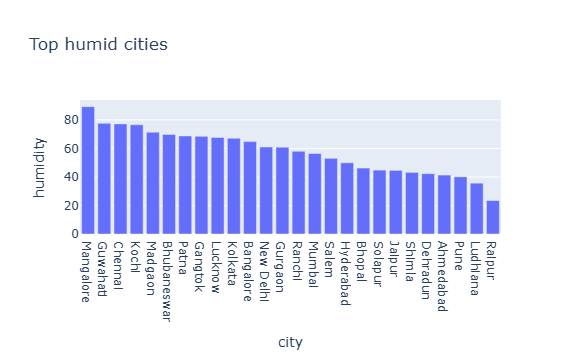

In [18]:
HumBar = px.bar(
    Humid,
    x='city',
    y='humidity',
    title='Top humid cities'
)
HumBar.show()

#### UV Analysis

##### Highest UV cities

In [19]:
UV = (
    df.groupby('city')['uv'].mean().sort_values(ascending=False).reset_index()
)
UV

,city,uv
0,Salem,3.05
1,Solapur,2.98
2,Mangalore,2.34
3,Pune,2.24
4,Mumbai,2.12
5,Kochi,2.07
6,Ahmedabad,2.05
7,Madgaon,2.03
8,Jaipur,1.96
9,Bhopal,1.92


In [20]:
UVBar = px.bar(
    UV,
    x='city',
    y='uv',
    color='uv',
    color_continuous_scale='purples',
    title='Top UV cities'
)
UVBar.show()

#### AQI vs Temperature

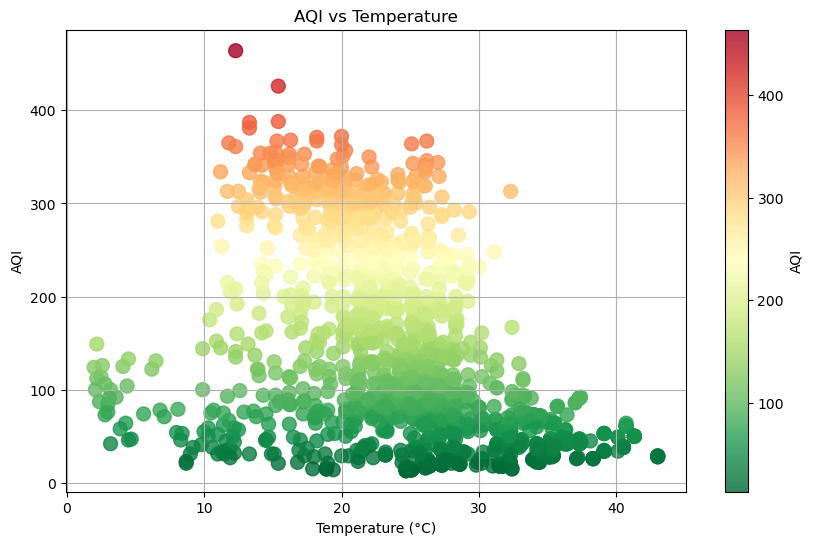

In [21]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["temp_c"],
    df["AQI_IN"],
    c=df["AQI_IN"],      # color by AQI
    cmap="RdYlGn_r",     # Green → Yellow → Red
    s=100,
    alpha=0.8
)

plt.colorbar(scatter, label="AQI")

plt.xlabel("Temperature (°C)")
plt.ylabel("AQI")
plt.title("AQI vs Temperature")

plt.grid(True)

plt.show()

#### AQI vs Wind Speed

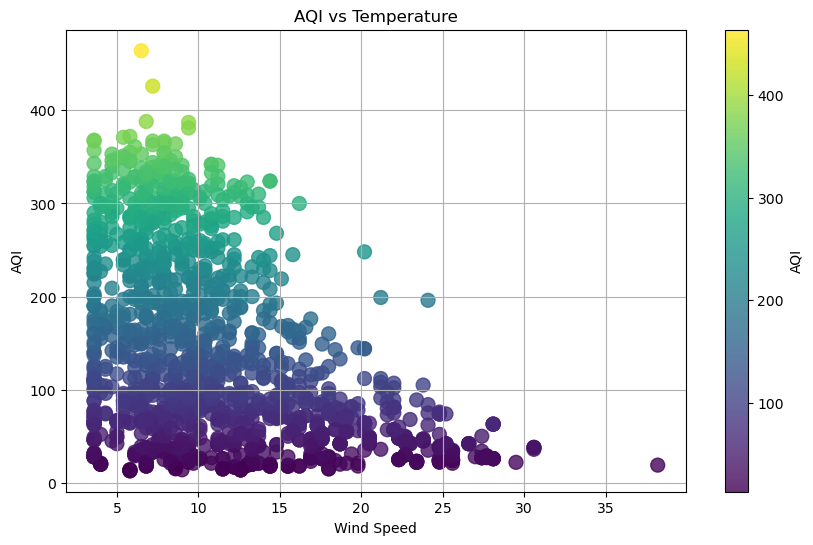

'\n# To print the cities too\nfor _, row in df.iterrows():\n    plt.annotate(\n        row["city"],\n        (row["temp_c"], row["AQI_IN"]),\n        fontsize=8\n    )\n\n'

In [25]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["wind_kph"],
    df["AQI_IN"],
    c=df["AQI_IN"],      # color by AQI
    cmap="viridis",     # Green → Yellow → Red
    s=100,
    alpha=0.8
)

plt.colorbar(scatter, label="AQI")

plt.xlabel("Wind Speed")
plt.ylabel("AQI")
plt.title("AQI vs Windspeed")

plt.grid(True)

plt.show()


"""
# To print the cities too
for _, row in df.iterrows():
    plt.annotate(
        row["city"],
        (row["temp_c"], row["AQI_IN"]),
        fontsize=8
    )

"""

#### AQI Vs UV

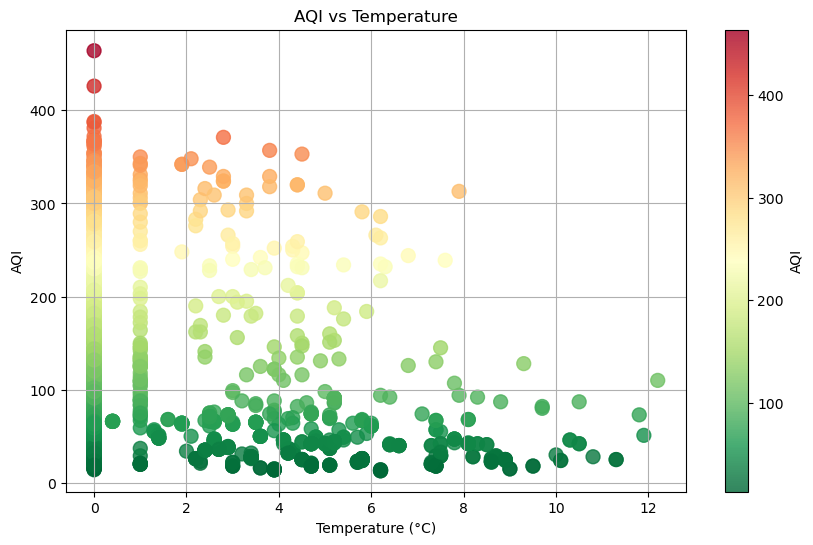

In [26]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["uv"],
    df["AQI_IN"],
    c=df["AQI_IN"],      # color by AQI
    cmap="RdYlGn_r",     # Green → Yellow → Red
    s=100,
    alpha=0.8
)

plt.colorbar(scatter, label="AQI")

plt.xlabel("Temperature (°C)")
plt.ylabel("AQI")
plt.title("AQI vs Temperature")

plt.grid(True)

plt.show()